# Figures

## Pfade

In [66]:
from pathlib import Path

TRAINING_ROOT   = Path("/home/sven/Desktop/git/3DMedDiffusion/Code/final")
EVAL_RESULTS    = TRAINING_ROOT / "results"
SAMPLES_ROOT    = Path("/home/sven/Desktop/diffsuion/Sample Generation")
CHECKPOINT_ROOT = Path("/home/sven/Desktop/diffsuion/Diff 2")
CODE_ROOT       = Path("/home/sven/Desktop/git/3DMedDiffusion/Code/unconditional")

OUTPUT_DIR = Path.cwd() / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

RNG_SEED = 42

FID_BEST_SAMPLER = {
    "baseline":          "DDPM",
    "data_augmentation": "UniPC",
    "linear_schedule":   "DDPM",
    "no_attention":      "DDPM",
    "noise_prediction":  "DDPM",
    "baseline_48":       "DDPM",
    "pipeline":          "UniPC",
}

print(OUTPUT_DIR)

/home/sven/Desktop/git/3DMedDiffusion/Code/figures/output


## Style

In [67]:
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.2,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

MODEL_COLORS = {
    "baseline":                                   "#1f77b4",
    "data_augmentation":                          "#ff7f0e",
    "linear_schedule":                            "#d62728",
    "no_attention":                               "#2ca02c",
    "noise_prediction":                           "#9467bd",
    "baseline_48":                                "#17becf",
    "conditional":                                "#8c564b",
    "novel_conditional_segmentation_classified":  "#bcbd22",
}

MODEL_LABELS = {
    "baseline":                                   r"Baseline $32^3$",
    "data_augmentation":                          "Data Augmentation",
    "linear_schedule":                            "Linearer Schedule",
    "no_attention":                               "Ohne Self-Attention",
    "noise_prediction":                           "Noise-Prediction",
    "baseline_48":                                r"Baseline $48^3$",
    "conditional":                                r"Maske $\rightarrow$ MRT",
    "novel_conditional_segmentation_classified":  r"Klasse $\rightarrow$ Maske",
}

SAMPLER_STEPS  = {"DDPM": 250, "DDIM": 50, "DPMSolverPP": 25, "UniPC": 10}
SAMPLER_LABELS = {"DDPM": "DDPM (250)", "DDIM": "DDIM (50)",
                  "DPMSolverPP": "DPM-Solver++ (25)", "UniPC": "UniPC (10)"}


def clean_axes(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)

## Helper

In [68]:
import nibabel as nib


def load_training_stats():
    out = {}
    for size_dir in sorted(TRAINING_ROOT.iterdir()):
        if not size_dir.is_dir() or not size_dir.name.isdigit():
            continue
        size = int(size_dir.name)
        for model_dir in sorted(size_dir.glob("output_*")):
            name = model_dir.name.replace("output_", "")
            sj = model_dir / "stats.json"
            if sj.exists():
                with sj.open() as f:
                    out[(size, name)] = json.load(f)
    return out


def load_volume(path):
    return nib.load(str(path)).get_fdata().astype(np.float32)


def axial_midslice(vol):
    return vol[:, :, vol.shape[2] // 2]


def norm01(img, vmin=-1.0, vmax=1.0):
    return np.clip((img - vmin) / (vmax - vmin), 0, 1)


def pick_indices(n_total, n_pick, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    return sorted(rng.choice(n_total, size=n_pick, replace=False).tolist())


def list_samples(folder, pattern="sample_*.nii.gz"):
    return sorted(folder.glob(pattern))

## Loss

In [69]:
all_stats = load_training_stats()
for k in all_stats:
    print(k)

(32, 'baseline')
(32, 'conditional')
(32, 'data_augmentation')
(32, 'linear_schedule')
(32, 'no_attention')
(32, 'noise_prediction')
(32, 'novel_conditional_segmentation_classified')
(48, 'baseline')


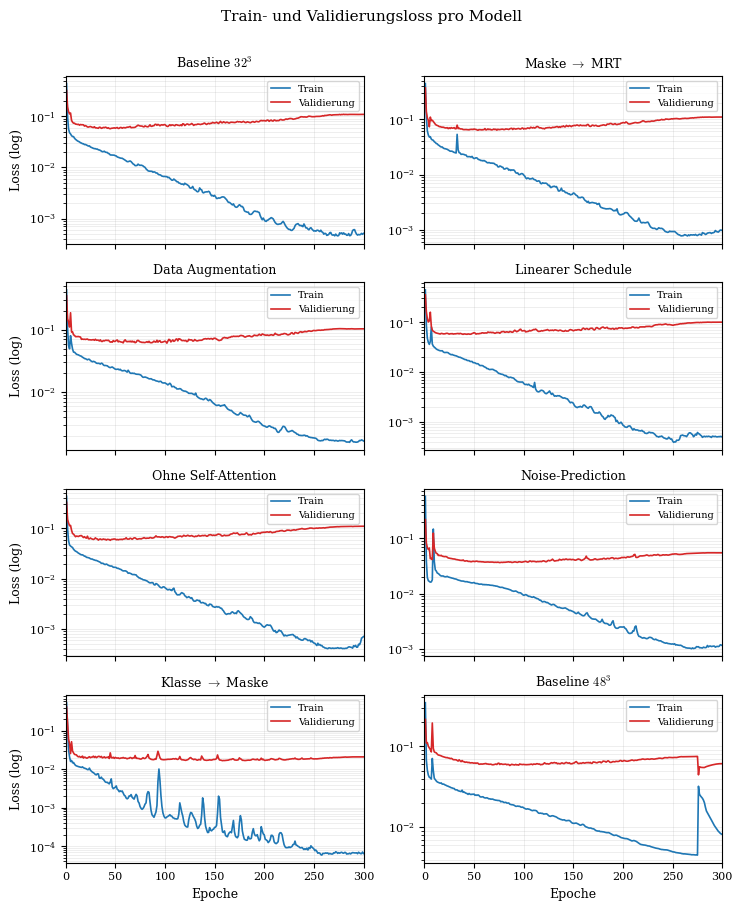

In [70]:
TRAIN_COLOR = "#1f77b4"
VAL_COLOR   = "#d62728"

models = sorted(all_stats.keys())

fig, axes = plt.subplots(4, 2, figsize=(7.5, 9), sharex=True)
flat = axes.flatten()

for ax, (size, name) in zip(flat, models):
    key = "baseline_48" if (size == 48 and name == "baseline") else name
    pem = all_stats[(size, name)]["per_epoch_metrics"]
    epochs = np.arange(1, len(pem["train_losses"]) + 1)
    ax.semilogy(epochs, pem["train_losses"], color=TRAIN_COLOR, label="Train")
    ax.semilogy(epochs, pem["val_losses"],   color=VAL_COLOR,   label="Validierung")
    ax.set_title(MODEL_LABELS.get(key, name), fontsize=9)
    ax.set_xlim(0, 300)
    ax.grid(True, which="both", alpha=0.3, linewidth=0.5)
    ax.legend(loc="upper right", fontsize=7)

for ax in flat[len(models):]:
    ax.axis("off")

for ax in axes[-1, :]:
    ax.set_xlabel("Epoche")
for ax in axes[:, 0]:
    ax.set_ylabel("Loss (log)")

fig.suptitle("Train- und Validierungsloss pro Modell", fontsize=11, y=1.005)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "loss_curves.pdf")
plt.show()

## Trainingsdauer

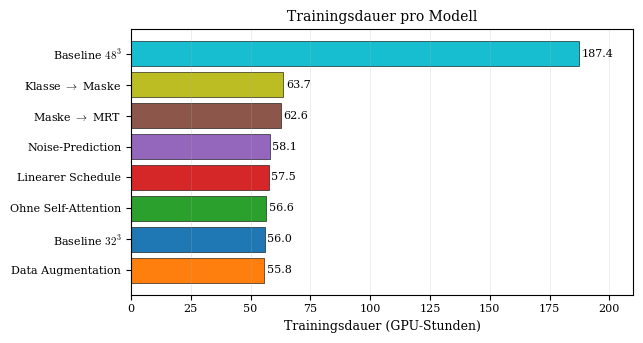

In [71]:
rows = []
for (size, name), st in all_stats.items():
    key = "baseline_48" if (size == 48 and name == "baseline") else name
    rows.append({
        "label": MODEL_LABELS.get(key, name),
        "hours": st["training_info"]["total_time_hours"],
        "color": MODEL_COLORS.get(key, "gray"),
    })
df = pd.DataFrame(rows).sort_values("hours")

fig, ax = plt.subplots(figsize=(6.5, 3.5))
bars = ax.barh(df["label"], df["hours"], color=df["color"], edgecolor="black", linewidth=0.4)
for b, h in zip(bars, df["hours"]):
    ax.text(h + 1, b.get_y() + b.get_height() / 2, f"{h:.1f}", va="center", fontsize=8)
ax.set_xlabel("Trainingsdauer (GPU-Stunden)")
ax.set_xlim(0, df["hours"].max() * 1.12)
ax.set_title("Trainingsdauer pro Modell")
ax.grid(True, axis="x", alpha=0.3, linewidth=0.5)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "training_time.pdf")
plt.show()

## Metriken

/tmp/ipykernel_6029/2457245499.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(arrs, labels=labels, patch_artist=True, widths=0.55,
/tmp/ipykernel_6029/2457245499.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(arrs, labels=labels, patch_artist=True, widths=0.55,
/tmp/ipykernel_6029/2457245499.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(arrs, labels=labels, patch_artist=True, widths=0.55,


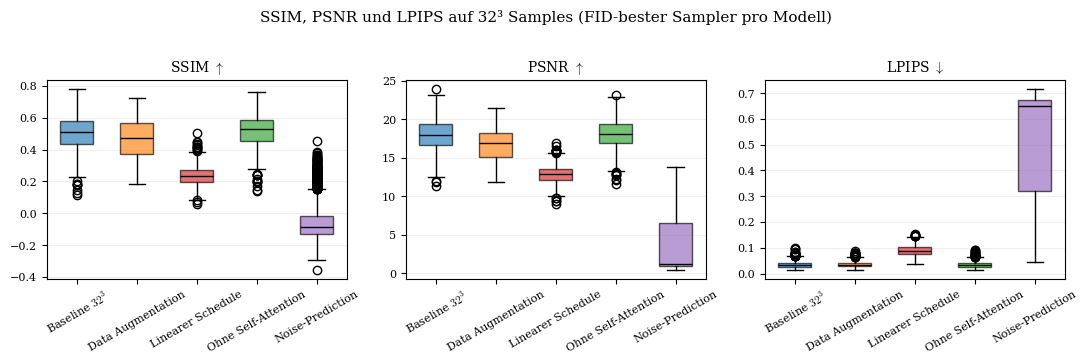

In [72]:
ablations = ["baseline", "data_augmentation", "linear_schedule", "no_attention", "noise_prediction"]

data = {m: {} for m in ablations}
for m in ablations:
    sampler = FID_BEST_SAMPLER[m]
    csv = EVAL_RESULTS / f"per_sample_unconditional_{m}_{sampler}_32.csv"
    if csv.exists():
        df = pd.read_csv(csv)
        data[m] = {col: df[col].values for col in ("ssim", "psnr", "lpips")}
    else:
        print(f"fehlt: {csv.name}")

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
metrics = [("ssim", r"SSIM $\uparrow$"), ("psnr", r"PSNR $\uparrow$"), ("lpips", r"LPIPS $\downarrow$")]

for ax, (metric, title) in zip(axes, metrics):
    arrs = [data[m][metric] for m in ablations if metric in data[m]]
    labels = [MODEL_LABELS[m] for m in ablations if metric in data[m]]
    bp = ax.boxplot(arrs, labels=labels, patch_artist=True, widths=0.55,
                    medianprops={"color": "black"})
    for patch, m in zip(bp["boxes"], ablations):
        patch.set_facecolor(MODEL_COLORS[m])
        patch.set_alpha(0.65)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(True, axis="y", alpha=0.3, linewidth=0.5)

fig.suptitle("SSIM, PSNR und LPIPS auf 32³ Samples (FID-bester Sampler pro Modell)",
             fontsize=11, y=1.02)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "boxplot_uncond_32.pdf")
plt.show()

## Sampler-Performance

In [73]:
def gen_stats(size=32):
    rows = []
    for sampler in ("DDPM", "DDIM", "DPMSolverPP", "UniPC"):
        p = SAMPLES_ROOT / sampler / str(size) / "samples_baseline" / "stats.json"
        if not p.exists():
            continue
        with p.open() as f:
            agg = json.load(f).get("aggregates", {})
        rows.append({
            "Sampler": sampler,
            "Schritte": SAMPLER_STEPS[sampler],
            "Zeit/Sample (s)":   round(agg.get("mean_time_per_sample", 0), 2),
            "Gesamtzeit (min)":  round(agg.get("total_time_sec", 0) / 60, 1),
            "Peak VRAM (GB)":    round(agg.get("peak_gpu_memory_nvidia_smi_gb", 0), 2),
        })
    return pd.DataFrame(rows)

for size in (32, 48):
    df = gen_stats(size)
    print(f"{size}^3:")
    print(df.to_string(index=False))
    df.to_csv(OUTPUT_DIR / f"generation_time_{size}.csv", index=False)
    print()

32^3:
    Sampler  Schritte  Zeit/Sample (s)  Gesamtzeit (min)  Peak VRAM (GB)
       DDPM       250            47.81             816.0            3.86
       DDIM        50             9.28             158.3            3.89
DPMSolverPP        25             4.60              78.5            3.86
      UniPC        10             1.68              28.7            4.28

48^3:
    Sampler  Schritte  Zeit/Sample (s)  Gesamtzeit (min)  Peak VRAM (GB)
       DDPM       250           151.45            2582.3            6.52
       DDIM        50            29.98             511.6            4.26
DPMSolverPP        25            14.92             254.7            4.66
      UniPC        10             5.70              97.3            4.34



## Samples (Anhang)

In [74]:
def sample_dir(size, sampler, model):
    return SAMPLES_ROOT / sampler / str(size) / f"samples_{model}" / "samples"


APPENDIX_SAMPLERS = ["DDPM", "DDIM", "DPMSolverPP", "UniPC"]
APPENDIX_IDX = pick_indices(1024, 1, seed=RNG_SEED)[0]

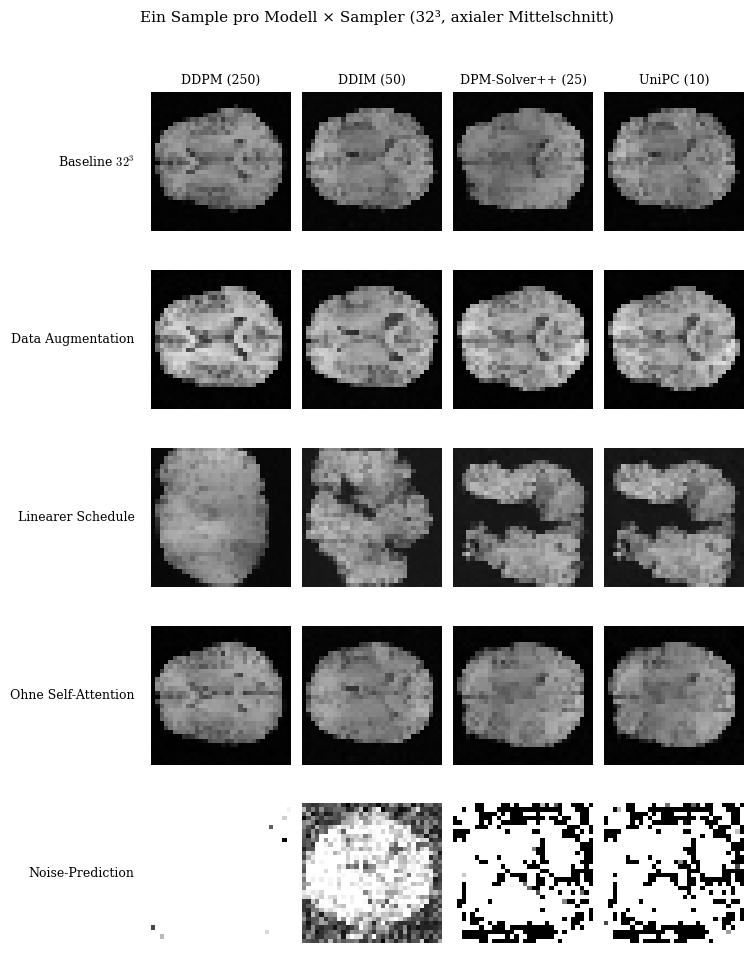

In [75]:
fig, axes = plt.subplots(len(ablations), len(APPENDIX_SAMPLERS),
                         figsize=(len(APPENDIX_SAMPLERS) * 1.9, len(ablations) * 1.9))

for r, m in enumerate(ablations):
    for c, sampler in enumerate(APPENDIX_SAMPLERS):
        ax = axes[r, c]
        files = list_samples(sample_dir(32, sampler, m))
        if files and APPENDIX_IDX < len(files):
            ax.imshow(norm01(axial_midslice(load_volume(files[APPENDIX_IDX]))),
                      cmap="gray", vmin=0, vmax=1)
        clean_axes(ax)
        if r == 0:
            ax.set_title(SAMPLER_LABELS[sampler], fontsize=9)
    axes[r, 0].set_ylabel(MODEL_LABELS[m], fontsize=9,
                          rotation=0, ha="right", va="center", labelpad=12)

fig.suptitle("Ein Sample pro Modell × Sampler (32³, axialer Mittelschnitt)",
             fontsize=11, y=1.01)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "samples_appendix_model_x_sampler_32.png")
plt.show()

## 32³ vs 48³

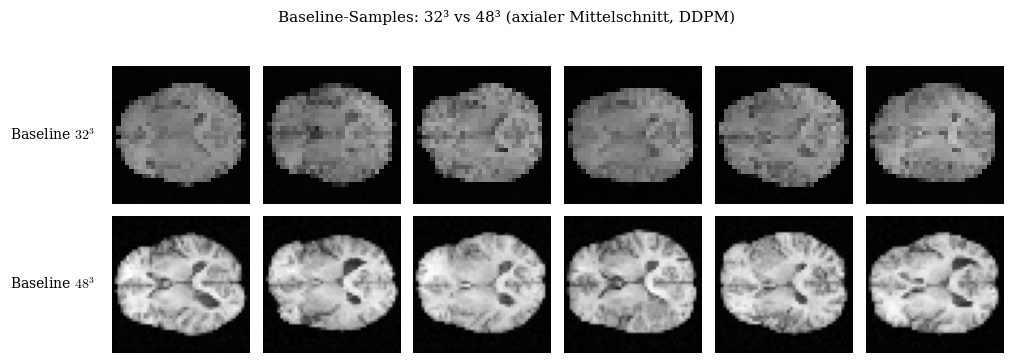

In [76]:
N_RES = 6
res_idx = pick_indices(1024, N_RES, seed=RNG_SEED + 1)

fig, axes = plt.subplots(2, N_RES, figsize=(N_RES * 1.7, 3.5))

for c, idx in enumerate(res_idx):
    f32 = list_samples(sample_dir(32, "DDPM", "baseline"))[idx]
    f48 = list_samples(sample_dir(48, "DDPM", "baseline"))[idx]
    axes[0, c].imshow(norm01(axial_midslice(load_volume(f32))), cmap="gray", vmin=0, vmax=1)
    axes[1, c].imshow(norm01(axial_midslice(load_volume(f48))), cmap="gray", vmin=0, vmax=1)
    clean_axes(axes[0, c])
    clean_axes(axes[1, c])

axes[0, 0].set_ylabel(r"Baseline $32^3$", fontsize=10, rotation=0, ha="right", va="center", labelpad=12)
axes[1, 0].set_ylabel(r"Baseline $48^3$", fontsize=10, rotation=0, ha="right", va="center", labelpad=12)

fig.suptitle("Baseline-Samples: 32³ vs 48³ (axialer Mittelschnitt, DDPM)",
             fontsize=11, y=1.03)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "samples_32_vs_48.png")
plt.show()

## Pipeline

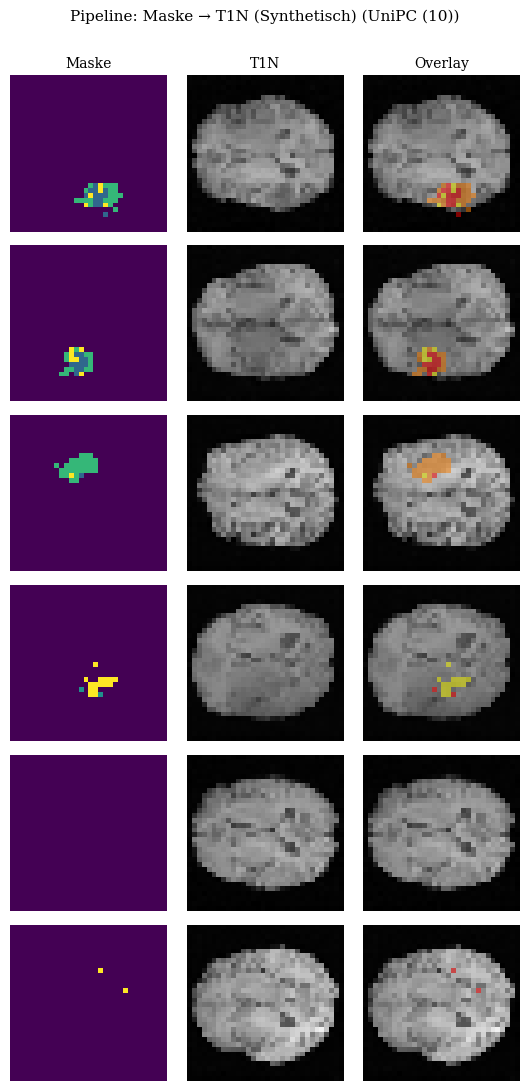

In [91]:
def pipeline_dir(sampler, size=32):
    return SAMPLES_ROOT / sampler / str(size) / "samples_pipeline" / "samples"


PIPE_SAMPLER = FID_BEST_SAMPLER["pipeline"]
N_PIPE = 6
pdir = pipeline_dir(PIPE_SAMPLER, 32)
brain_files = sorted(pdir.glob("brain_*.nii.gz"))
tumor_files = sorted(pdir.glob("tumor_*.nii.gz"))

pipe_idx = pick_indices(len(brain_files), N_PIPE, seed=RNG_SEED + 2)
fig, axes = plt.subplots(N_PIPE, 3, figsize=(5.5, N_PIPE * 1.8))

for r, idx in enumerate(pipe_idx):
    brain = axial_midslice(load_volume(brain_files[idx]))
    tumor = axial_midslice(load_volume(tumor_files[idx]))
    axes[r, 0].imshow(tumor, cmap="viridis", vmin=0, vmax=max(tumor.max(), 1))
    axes[r, 1].imshow(norm01(brain), cmap="gray", vmin=0, vmax=1)
    axes[r, 2].imshow(norm01(brain), cmap="gray", vmin=0, vmax=1)
    axes[r, 2].imshow(np.ma.masked_where(tumor == 0, tumor), cmap="autumn", alpha=0.5)
    for c in range(3):
        clean_axes(axes[r, c])

axes[0, 0].set_title("Maske")
axes[0, 1].set_title("T1N")
axes[0, 2].set_title("Overlay")

fig.suptitle(f"Pipeline: Maske → T1N (Synthetisch) ({SAMPLER_LABELS[PIPE_SAMPLER]})",
             fontsize=11, y=1.005)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "samples_pipeline_grid.png")
plt.show()

## Modell laden

In [78]:
sys.path.insert(0, str(CODE_ROOT / "src"))

from dataclasses import dataclass
from typing import Tuple
import torch

from model.unet3d import UNet3D
from sampler.sampler import make_scheduler


@dataclass
class Config:
    data_path: str = ""
    output_path: str = ""
    image_size: int = 32
    in_channels: int = 1
    model_channels: int = 96
    channel_mult: Tuple[int, ...] = (1, 2, 4, 4)
    num_res_blocks: int = 2
    attention_resolutions: Tuple[int, ...] = (8, 4)
    num_groups: int = 8
    dropout: float = 0.0
    num_timesteps: int = 250
    beta_schedule: str = "cosine"
    prediction_type: str = "v"
    num_epochs: int = 300
    batch_size: int = 10
    learning_rate: float = 2e-4
    warmup_steps: int = 500
    ema_decay: float = 0.9999
    grad_clip: float = 1.0
    use_loss_aware_sampling: bool = True
    loss_history_size: int = 10
    snr_gamma: float = 5.0
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


# torch.load(weights_only=False) sucht Config in __main__
sys.modules.setdefault("__main__", sys.modules[__name__])
setattr(sys.modules["__main__"], "Config", Config)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def load_model(ckpt_path, image_size=32, attention_resolutions=(8, 4),
               prediction_type="v", beta_schedule="cosine"):
    cfg = Config(image_size=image_size, attention_resolutions=attention_resolutions,
                 prediction_type=prediction_type, beta_schedule=beta_schedule)
    model = UNet3D(cfg).to(DEVICE)
    ckpt = torch.load(str(ckpt_path), map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model"])
    if "ema" in ckpt and "shadow" in ckpt["ema"]:
        for n, p in model.named_parameters():
            if n in ckpt["ema"]["shadow"]:
                p.data.copy_(ckpt["ema"]["shadow"][n].to(DEVICE))
    model.eval()
    return model


@torch.no_grad()
def sample_trajectory(model, scheduler, image_size, num_steps, n_capture=8, seed=RNG_SEED):
    scheduler.set_timesteps(num_steps)
    torch.manual_seed(seed)
    x = torch.randn(1, 1, image_size, image_size, image_size, device=DEVICE)
    capture_after = set(np.linspace(0, num_steps - 1, n_capture - 1).astype(int).tolist())
    caps = [x.clone()]
    for i, t in enumerate(scheduler.timesteps):
        tb = torch.full((1,), int(t), device=DEVICE, dtype=torch.long)
        with torch.amp.autocast("cuda", dtype=torch.float16):
            pred = model(x, tb).float()
        x = scheduler.step(pred, t, x).prev_sample
        if i in capture_after:
            caps.append(x.clone())
    if len(caps) < n_capture:
        caps.append(x.clamp(-1, 1).clone())
    return caps

## Trainings-Progression

ep 1: epoch_1.pt
ep 10: epoch_10.pt
ep 25: epoch_25.pt
ep 50: epoch_50.pt
ep 100: epoch_100.pt
ep 150: epoch_150.pt
ep 200: epoch_200.pt
ep 250: epoch_250.pt
ep 300: final_model.pt


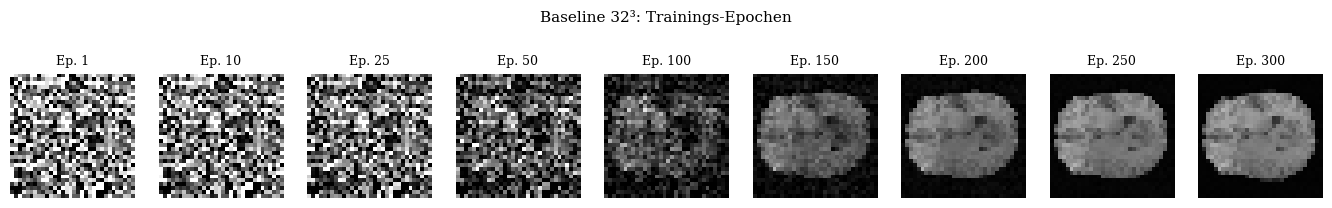

In [79]:
CKPT_EPOCHS = [1, 10, 25, 50, 100, 150, 200, 250, 300]
ckpt_dir = CHECKPOINT_ROOT / "32" / "output_baseline" / "checkpoints"


def find_ckpt(epoch):
    if epoch == 300:
        p = ckpt_dir / "final_model.pt"
        if p.exists():
            return p
    for tpl in (f"checkpoint_epoch_{epoch:03d}.pt", f"checkpoint_epoch_{epoch}.pt",
                f"epoch_{epoch:03d}.pt", f"epoch_{epoch}.pt"):
        p = ckpt_dir / tpl
        if p.exists():
            return p
    return None


prog_samples = []
prog_labels = []
for ep in CKPT_EPOCHS:
    cp = find_ckpt(ep)
    if cp is None:
        print(f"skip ep {ep}")
        continue
    print(f"ep {ep}: {cp.name}")
    model = load_model(cp)
    scheduler = make_scheduler("ddpm", "cosine", "v")
    scheduler.set_timesteps(250)
    torch.manual_seed(RNG_SEED)
    x = torch.randn(1, 1, 32, 32, 32, device=DEVICE)
    with torch.no_grad():
        for t in scheduler.timesteps:
            tb = torch.full((1,), int(t), device=DEVICE, dtype=torch.long)
            with torch.amp.autocast("cuda", dtype=torch.float16):
                pred = model(x, tb).float()
            x = scheduler.step(pred, t, x).prev_sample
    prog_samples.append(x.clamp(-1, 1).squeeze().cpu().numpy())
    prog_labels.append(f"Ep. {ep}")
    del model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

n = len(prog_samples)
fig, axes = plt.subplots(1, n, figsize=(n * 1.5, 1.8))
for ax, vol, lbl in zip(axes, prog_samples, prog_labels):
    ax.imshow(norm01(axial_midslice(vol)), cmap="gray", vmin=0, vmax=1)
    ax.set_title(lbl, fontsize=9)
    clean_axes(ax)
fig.suptitle("Baseline 32³: Trainings-Epochen", fontsize=11, y=1.12)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "training_progression.png")
plt.show()

## Denoising-Trajektorie

In [80]:
N_STEPS_SHOW = 8
SAMPLER_MAP = {"DDPM": ("ddpm", 250), "DDIM": ("ddim", 50),
               "DPMSolverPP": ("dpm_solver++", 25), "UniPC": ("unipc", 10)}


def trajectories(image_size, attn):
    cp = CHECKPOINT_ROOT / str(image_size) / "output_baseline" / "checkpoints" / "final_model.pt"
    if not cp.exists():
        print(f"kein Checkpoint: {cp}")
        return {}
    model = load_model(cp, image_size=image_size, attention_resolutions=attn)
    out = {}
    for name, (key, steps) in SAMPLER_MAP.items():
        scheduler = make_scheduler(key, "cosine", "v")
        caps = sample_trajectory(model, scheduler, image_size, steps,
                                 n_capture=min(N_STEPS_SHOW, steps + 1),
                                 seed=RNG_SEED)
        out[name] = [c.squeeze().cpu().numpy() for c in caps]
    del model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    return out


traj_32 = trajectories(32, (8, 4))
traj_48 = trajectories(48, (12, 6))

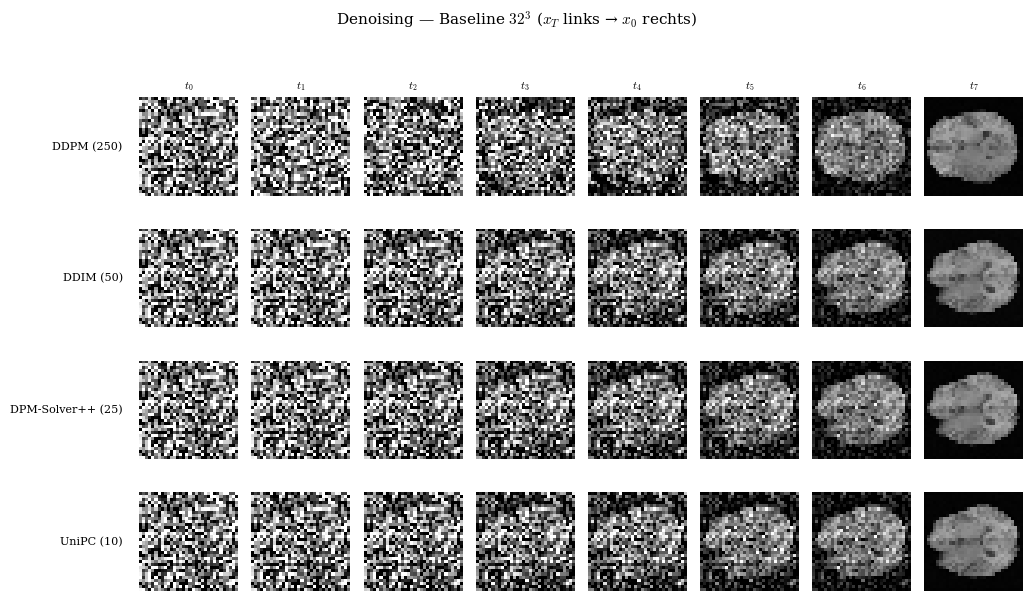

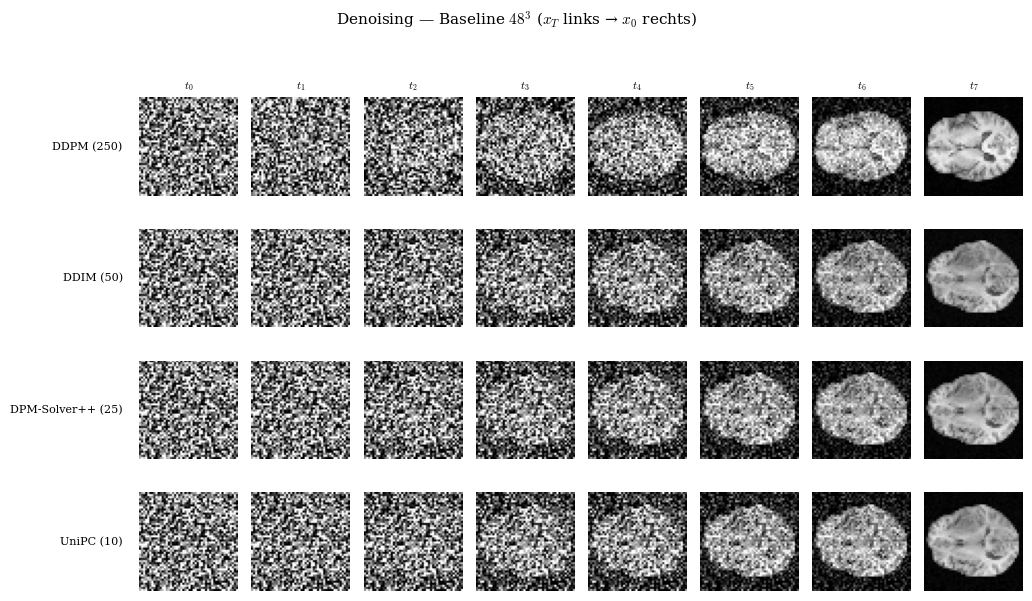

In [81]:
def plot_trajectory(traj, image_size, suffix):
    if not traj:
        return
    samplers = list(traj.keys())
    n_steps = max(len(v) for v in traj.values())

    fig, axes = plt.subplots(len(samplers), n_steps, figsize=(n_steps * 1.3, len(samplers) * 1.5))

    for r, name in enumerate(samplers):
        vols = traj[name]
        for c in range(n_steps):
            ax = axes[r, c]
            if c < len(vols):
                ax.imshow(norm01(axial_midslice(vols[c])), cmap="gray", vmin=0, vmax=1)
            clean_axes(ax)
            if r == 0:
                ax.set_title(f"$t_{{{c}}}$", fontsize=8)
        axes[r, 0].set_ylabel(SAMPLER_LABELS[name], fontsize=8,
                              rotation=0, ha="right", va="center", labelpad=12)

    fig.suptitle(f"Denoising — Baseline ${image_size}^3$ "
                 r"($x_T$ links → $x_0$ rechts)",
                 fontsize=11, y=1.02)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"denoising_trajectory_{suffix}.png")
    plt.show()


plot_trajectory(traj_32, 32, "32")
plot_trajectory(traj_48, 48, "48")

## Sampler-Vergleich

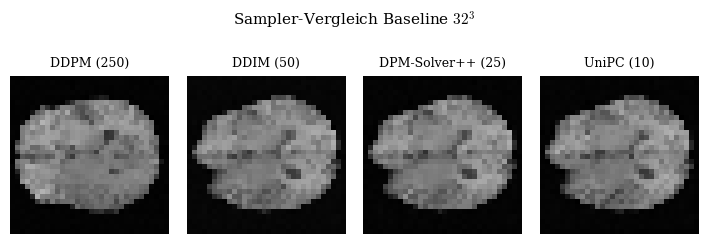

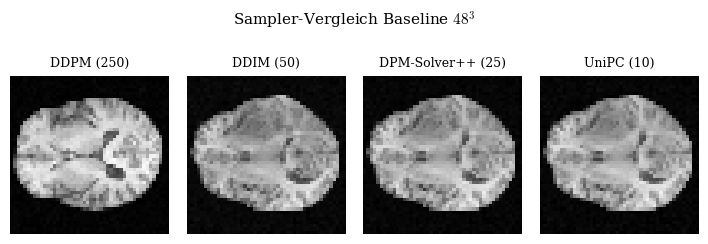

In [82]:
def plot_sampler_compare(traj, image_size, suffix):
    if not traj:
        return
    samplers = list(traj.keys())
    fig, axes = plt.subplots(1, len(samplers), figsize=(len(samplers) * 1.8, 2.2))
    for ax, name in zip(axes, samplers):
        ax.imshow(norm01(axial_midslice(traj[name][-1])), cmap="gray", vmin=0, vmax=1)
        ax.set_title(SAMPLER_LABELS[name], fontsize=9)
        clean_axes(ax)
    fig.suptitle(f"Sampler-Vergleich Baseline ${image_size}^3$",
                 fontsize=11, y=1.08)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"samples_sampler_compare_{suffix}.png")
    plt.show()


plot_sampler_compare(traj_32, 32, "32")
plot_sampler_compare(traj_48, 48, "48")

## Vollseiten-Sample-Grids (Anhang)
Pro Sampler ein Grid (5 Modelle × 8 Samples). Vier separate Figuren — eine pro Sampler.

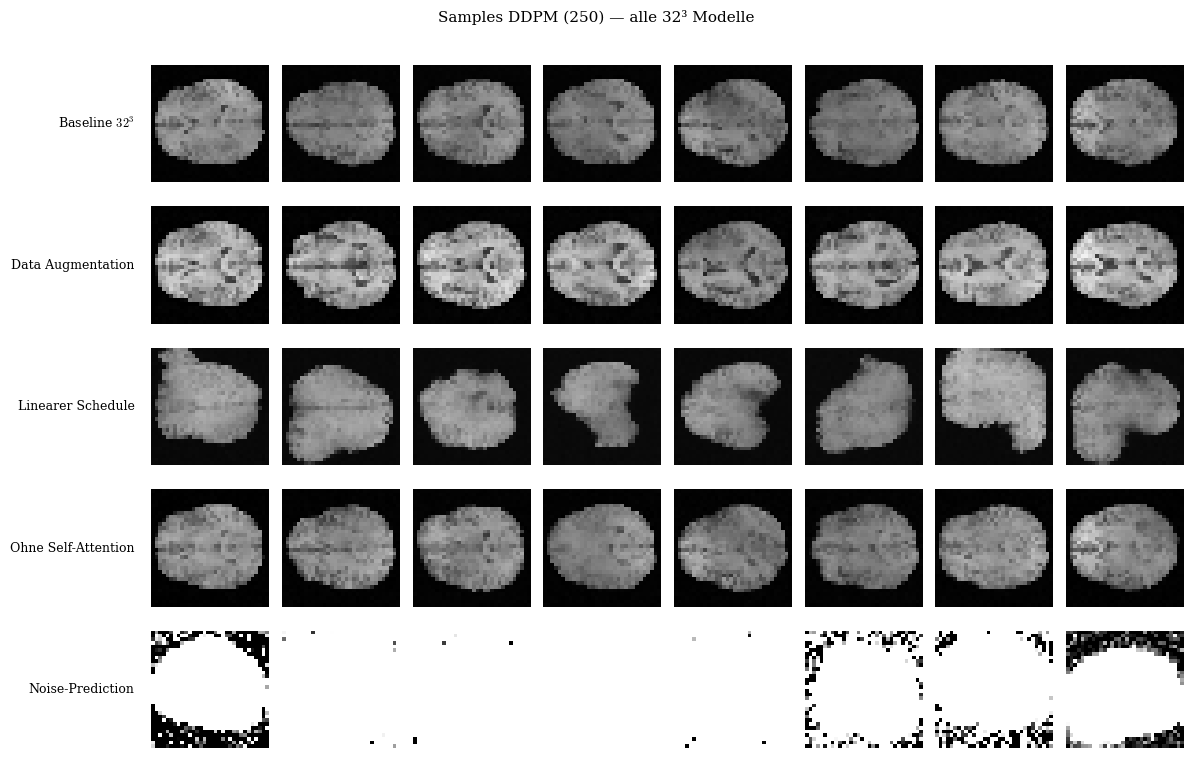

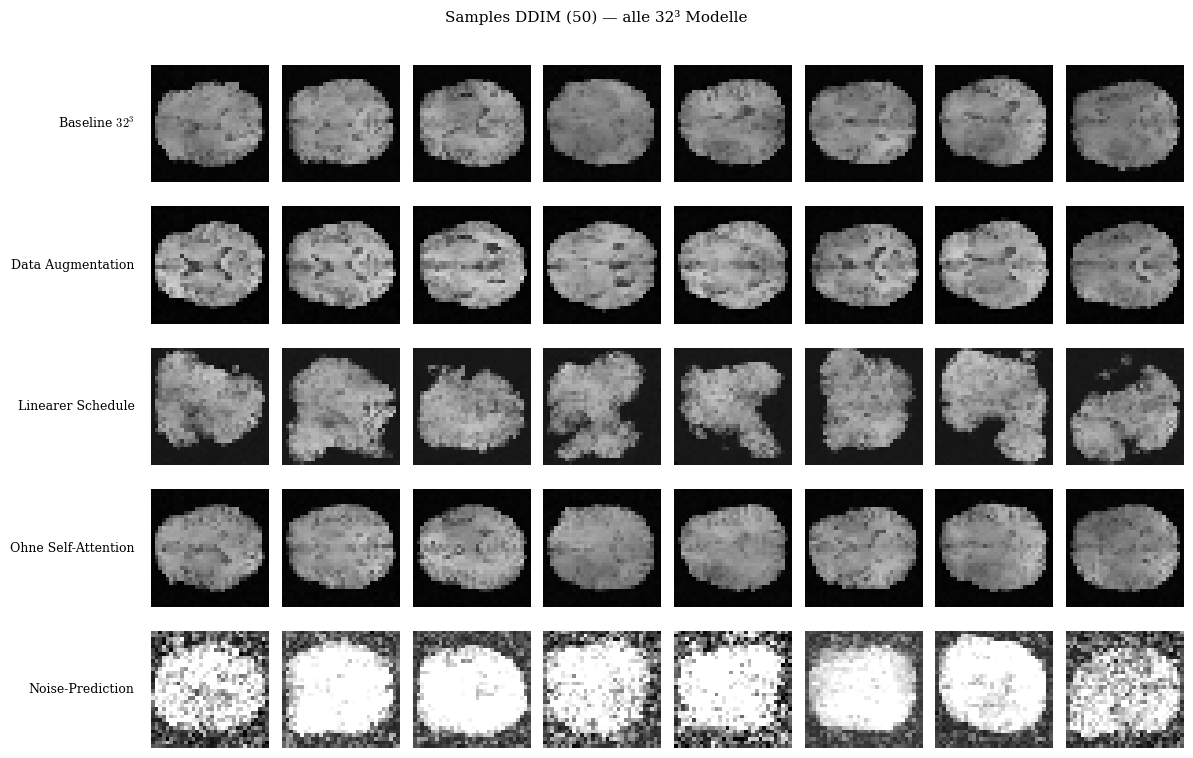

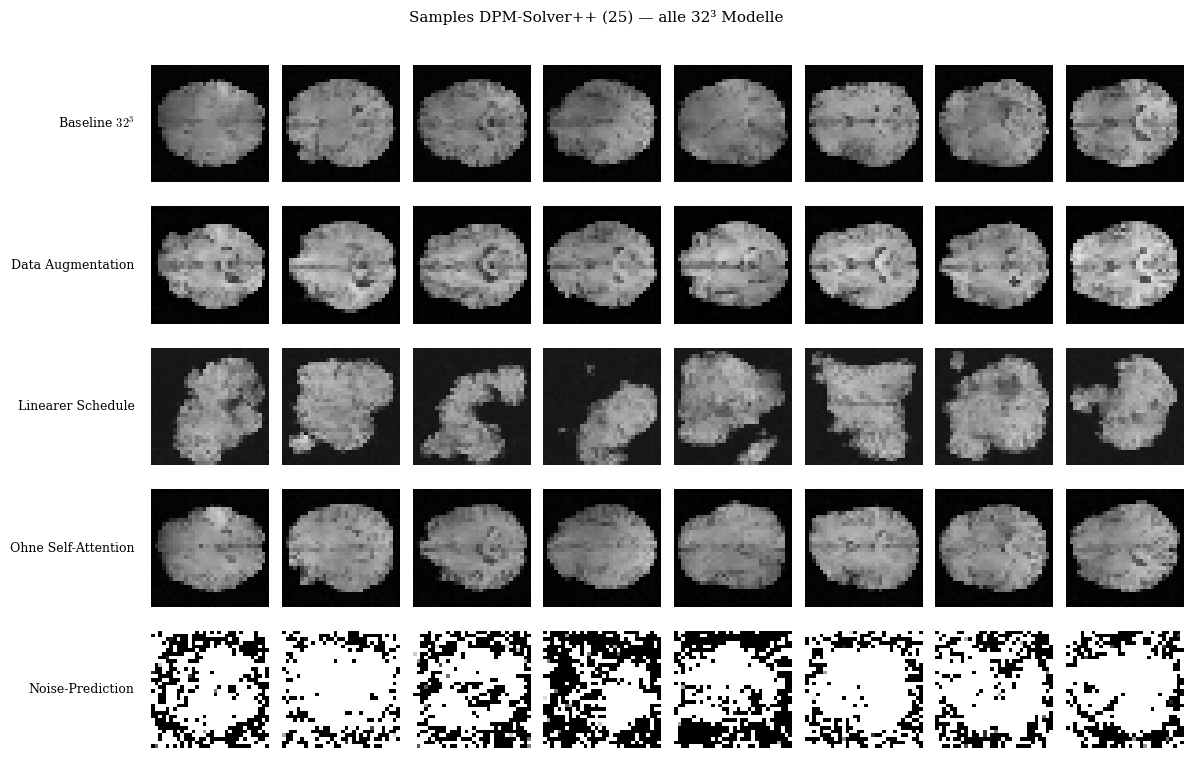

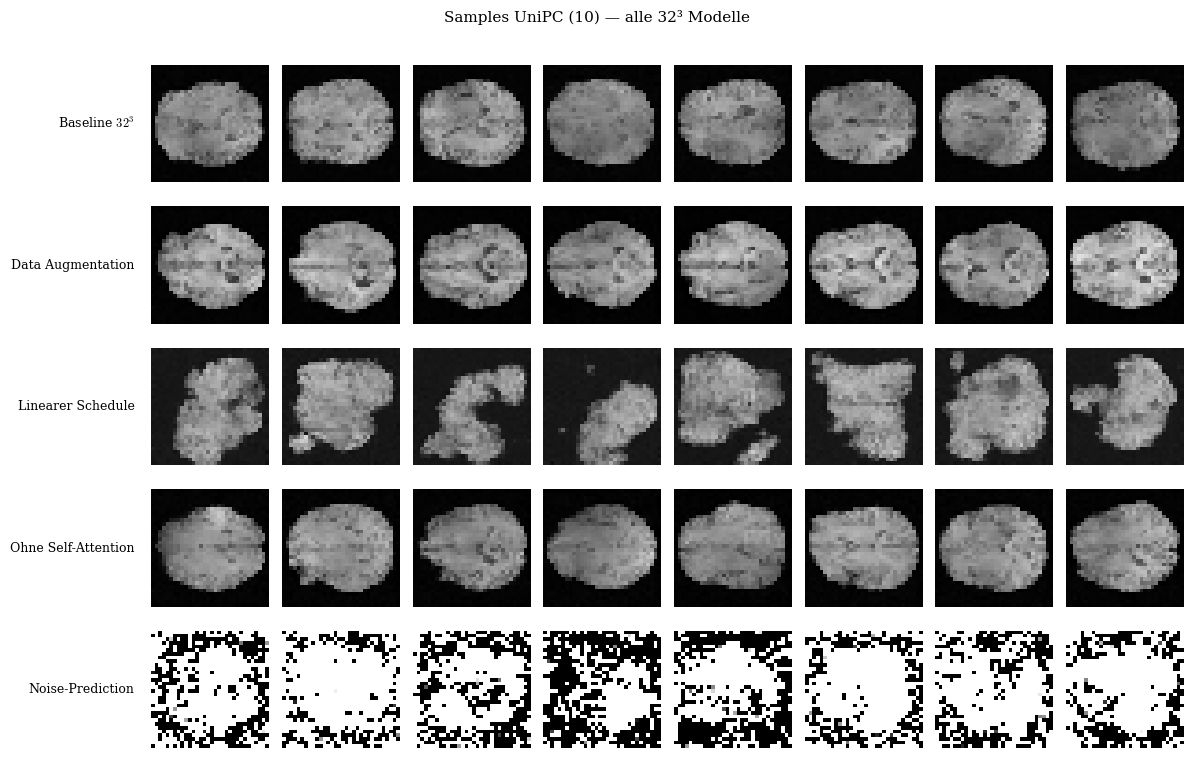

In [83]:
N_FULL = 8
full_idx = pick_indices(1024, N_FULL, seed=RNG_SEED + 5)

for sampler in APPENDIX_SAMPLERS:
    fig, axes = plt.subplots(len(ablations), N_FULL,
                             figsize=(N_FULL * 1.5, len(ablations) * 1.5))
    for r, m in enumerate(ablations):
        files = list_samples(sample_dir(32, sampler, m))
        for c, idx in enumerate(full_idx):
            ax = axes[r, c]
            if files and idx < len(files):
                ax.imshow(norm01(axial_midslice(load_volume(files[idx]))),
                          cmap="gray", vmin=0, vmax=1)
            clean_axes(ax)
        axes[r, 0].set_ylabel(MODEL_LABELS[m], fontsize=9,
                              rotation=0, ha="right", va="center", labelpad=12)
    fig.suptitle(f"Samples {SAMPLER_LABELS[sampler]} — alle 32³ Modelle",
                 fontsize=11, y=1.01)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"samples_appendix_full_{sampler}.png")
    plt.show()

## 3D-Ansicht
Triplanare Mittelschnitte (axial / koronal / sagittal) und 3D-Isofläche für Baseline 32³, Baseline 48³ und die Pipeline.

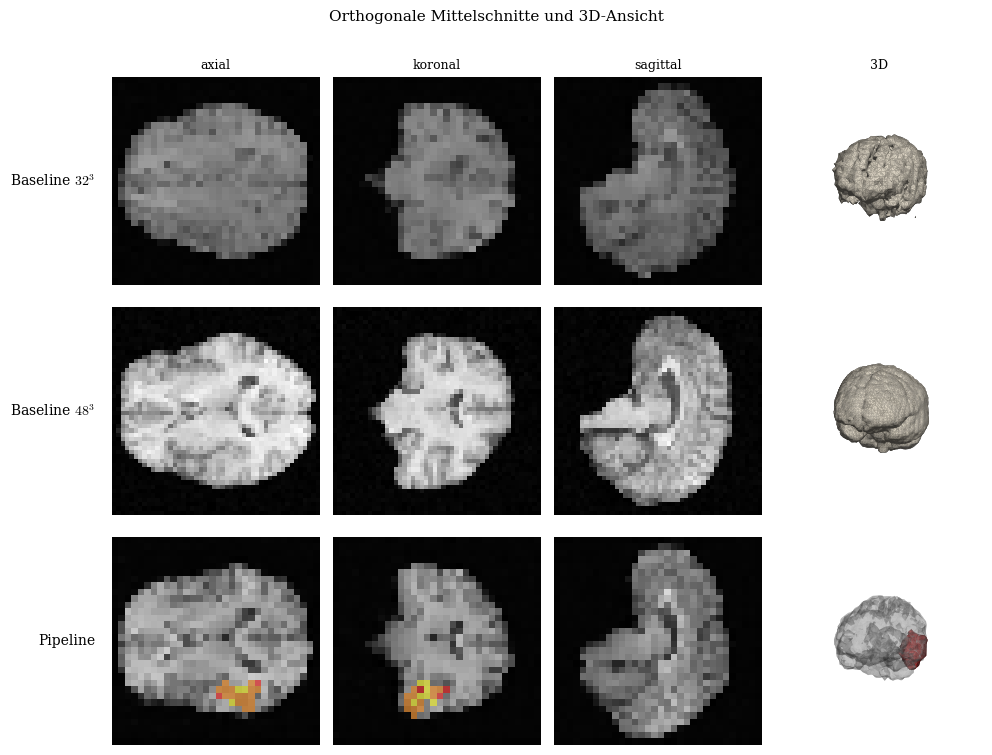

In [86]:
from skimage import measure
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


def triplanar(vol):
    sx, sy, sz = vol.shape
    return vol[:, :, sz // 2], vol[:, sy // 2, :], vol[sx // 2, :, :]


def render_isosurface(ax, vol, level, base_color="#d8d0c0", alpha=1.0,
                      light_dir=(0.4, -0.7, 0.5), ambient=0.25):
    try:
        verts, faces, normals, _ = measure.marching_cubes(vol, level=level)
    except (ValueError, RuntimeError):
        return
    # Diffuse Beleuchtung über Face-Normalen — monochrom, wie in 3D Slicer.
    fn = normals[faces].mean(axis=1)
    fn = fn / (np.linalg.norm(fn, axis=1, keepdims=True) + 1e-9)
    L = np.array(light_dir, dtype=np.float32)
    L = L / np.linalg.norm(L)
    shading = ambient + (1 - ambient) * np.clip(fn @ L, 0, 1)
    base = np.array(mpl.colors.to_rgb(base_color))
    face_colors = np.clip(shading[:, None] * base[None, :], 0, 1)
    mesh = Poly3DCollection(verts[faces], alpha=alpha)
    mesh.set_facecolor(face_colors)
    mesh.set_edgecolor("none")
    ax.add_collection3d(mesh)
    ax.set_xlim(0, vol.shape[0])
    ax.set_ylim(0, vol.shape[1])
    ax.set_zlim(0, vol.shape[2])
    ax.set_box_aspect((1, 1, 1))
    ax.set_axis_off()


idx_3d = pick_indices(1024, 1, seed=RNG_SEED + 6)[0]

b32 = load_volume(list_samples(sample_dir(32, "DDPM", "baseline"))[idx_3d])
b48 = load_volume(list_samples(sample_dir(48, "DDPM", "baseline"))[idx_3d])
pipe_b = load_volume(brain_files[idx_3d])
pipe_t = load_volume(tumor_files[idx_3d])

views = ["axial", "koronal", "sagittal"]
rows = [(r"Baseline $32^3$", b32, None),
        (r"Baseline $48^3$", b48, None),
        ("Pipeline",         pipe_b, pipe_t)]

fig = plt.figure(figsize=(10, 7.5))

for r, (label, vol, tumor) in enumerate(rows):
    slices = triplanar(vol)
    t_slices = triplanar(tumor) if tumor is not None else (None, None, None)

    for c in range(3):
        ax = fig.add_subplot(3, 4, r * 4 + c + 1)
        ax.imshow(norm01(slices[c]), cmap="gray", vmin=0, vmax=1)
        if t_slices[c] is not None:
            ts = t_slices[c]
            ax.imshow(np.ma.masked_where(ts == 0, ts), cmap="autumn", alpha=0.5)
        clean_axes(ax)
        if r == 0:
            ax.set_title(views[c], fontsize=9)
        if c == 0:
            ax.set_ylabel(label, fontsize=10, rotation=0, ha="right", va="center", labelpad=12)

    ax3d = fig.add_subplot(3, 4, r * 4 + 4, projection="3d")
    if tumor is None:
        render_isosurface(ax3d, vol, level=-0.2, base_color="#d8d0c0", alpha=1.0)
    else:
        render_isosurface(ax3d, vol, level=-0.2, base_color="#c8c8c8", alpha=0.30)
        render_isosurface(ax3d, (tumor > 0).astype(np.float32), level=0.5,
                          base_color="#c83838", alpha=1.0)
    ax3d.view_init(elev=15, azim=-70)
    if r == 0:
        ax3d.set_title("3D", fontsize=9)

fig.suptitle("Orthogonale Mittelschnitte und 3D-Ansicht", fontsize=11, y=1.005)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "triplanar_views.png")
plt.show()

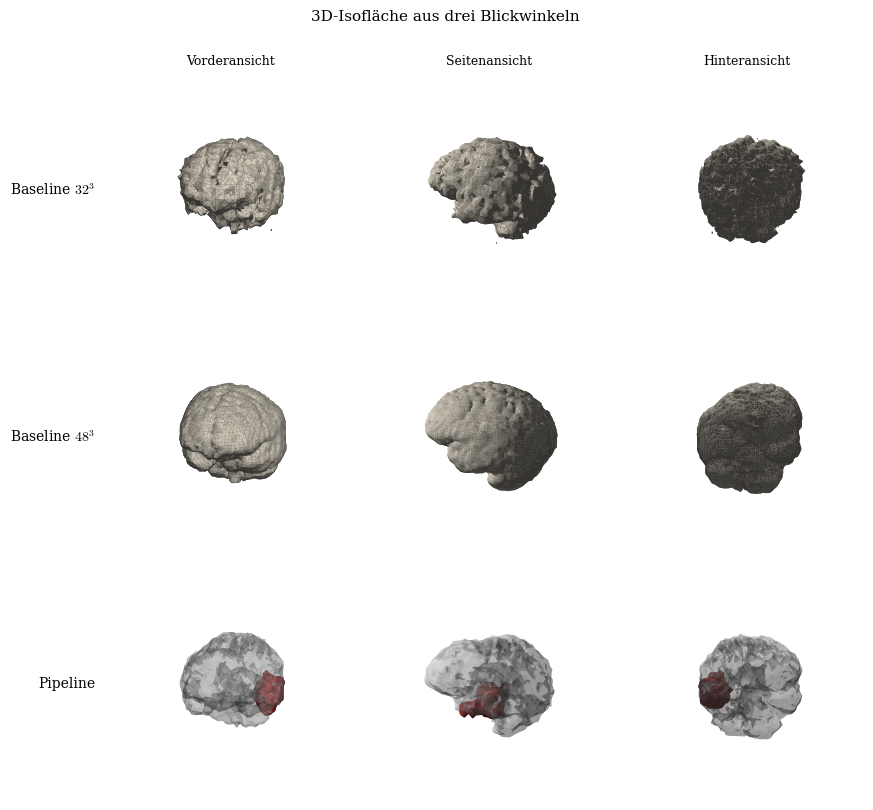

In [87]:
ANGLES = [(15, -70), (15, 20), (15, 110)]
angle_labels = ["Vorderansicht", "Seitenansicht", "Hinteransicht"]

iso_rows = [(r"Baseline $32^3$", b32, None),
            (r"Baseline $48^3$", b48, None),
            ("Pipeline",         pipe_b, pipe_t)]

fig = plt.figure(figsize=(9, 8))

for r, (label, vol, tumor) in enumerate(iso_rows):
    for c, (elev, azim) in enumerate(ANGLES):
        ax = fig.add_subplot(3, 3, r * 3 + c + 1, projection="3d")
        if tumor is None:
            render_isosurface(ax, vol, level=-0.2, base_color="#d8d0c0", alpha=1.0)
        else:
            render_isosurface(ax, vol, level=-0.2, base_color="#c8c8c8", alpha=0.30)
            render_isosurface(ax, (tumor > 0).astype(np.float32), level=0.5,
                              base_color="#c83838", alpha=1.0)
        ax.view_init(elev=elev, azim=azim)
        if r == 0:
            ax.set_title(angle_labels[c], fontsize=9)
        if c == 0:
            ax.text2D(-0.08, 0.5, label, transform=ax.transAxes,
                      fontsize=10, ha="right", va="center")

fig.suptitle("3D-Isofläche aus drei Blickwinkeln", fontsize=11, y=1.005)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "isosurface_3d.png")
plt.show()